In [1]:
#PACKAGES
import numpy as np
import pylab
import math
import matplotlib.pyplot as plt
from matplotlib import rcParams
#from pyunicorn.core import Network
from pyunicorn.timeseries import RecurrenceNetwork
from pyunicorn.timeseries import RecurrencePlot
from pyunicorn.core import Network
rcParams.update({'font.size': 15})
plt.rcParams['figure.figsize'] = [7, 5]
import sys,os, shutil
from packaging import version
import importlib
import pandas as pd
import subprocess as sb
import glob
from tqdm import tqdm
import warnings
!chmod +x ./mutual
!chmod +x ./false_nearest
warnings.filterwarnings("ignore", category=RuntimeWarning)

chmod: cannot access './surrogates': No such file or directory


In [2]:
#FUNCTIONS
def open_file(rootfilename, dimension,thr):
    surro_DET = []
    surro_LAM = []
    surro_ENTR = []
    for i in range(1,10):
        file = rootfilename + "_00" + str(i) 
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension, tau=t_min, metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
        data = []
    for j in range (10, 100):
        file = rootfilename + "_0" + str(j)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension , tau=t_min,  metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
        data = []
    return surro_DET, surro_LAM, surro_ENTR

def lcurve(p):
    lc = np.loadtxt("{}".format(p), delimiter=" ", usecols=0)
    j = lc
    np.savetxt("surro_index/qp", j)
    return j


def RP_RN(l, dimension, thr):
    qpo_rp = RecurrencePlot(l, dim=dimension , tau=t_min, metric = "euclidean", threshold=thr, normalize=True, silence_level = 3)
    RRqpo = qpo_rp.recurrence_rate()
    DETqpo = qpo_rp.determinism(l_min=2)
    LAMqpo = qpo_rp.laminarity(v_min=2)
    ENTRqpo = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)
    return DETqpo, RRqpo, LAMqpo, ENTRqpo

def sur_test(l, m, thr):
    kk = []
    os.system("./surrogates surro_index/qp -S -n100 -o -V0")
    a, b, c = open_file("surro_index/qp_surr", m, thr)
    d, e, z, u= RP_RN(l, m, thr)
    return a, b, c

In [3]:
data1 = np.loadtxt("psei.csv", delimiter =',', usecols =(1) , skiprows=1)*1000
data2 = np.loadtxt("psei.csv", delimiter =',', usecols =(2) , skiprows=1)
data = data1 + data2
np.savetxt("stocks", data)

In [4]:

import subprocess
subprocess.run(["julia", "WIAAFT_surrogates.jl"], capture_output=True, text=True, check=True)


CompletedProcess(args=['julia', 'WIAAFT_surrogates.jl'], returncode=0, stdout='', stderr='')

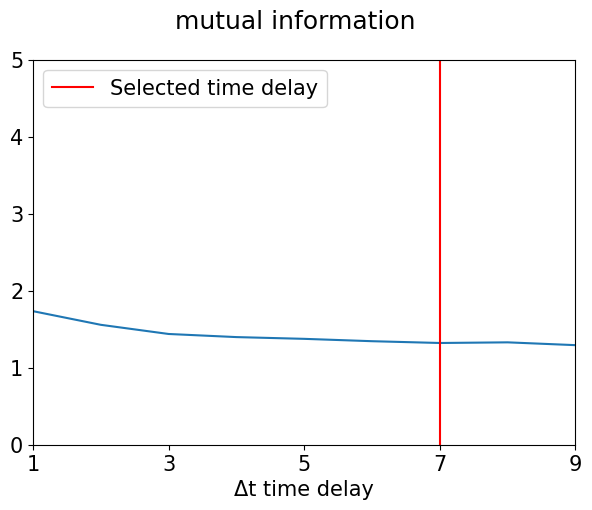

In [5]:
m_site1 = np.loadtxt("files/mutual_stocks", delimiter =' ', usecols =(1) , skiprows=0)
fig2, axs = plt.subplots(1)
fig2.suptitle("mutual information")
axs.plot(m_site1)
plt.axvline(x = 7, color = 'red', label = 'Selected time delay')
plt.xticks(range(1,21,2))
axs.set_xlim([1, 9])
axs.set_ylim([0, 5])
plt.xlabel("Δt time delay")
plt.legend()
plt.show()

/tmp/ipykernel_9632/147840257.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0, 5])


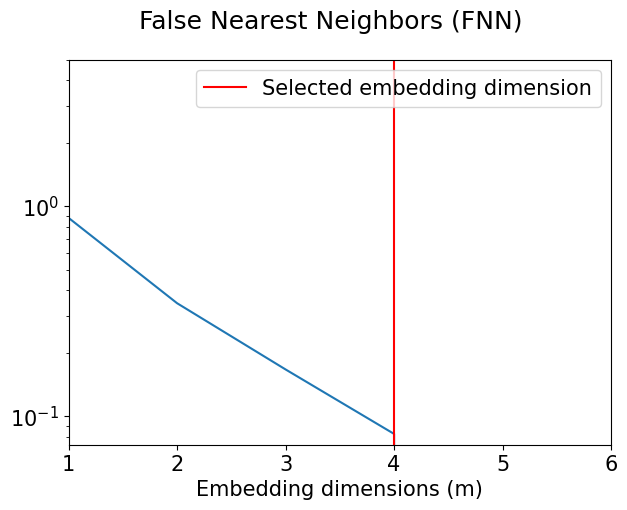

In [6]:
m1 = np.loadtxt("files/stocks.fnn", usecols=1)
d1 = np.loadtxt("files/stocks.fnn", usecols=0)
fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1, m1/d1)
ax.set_yscale("log")
plt.xticks(range(1,20,1))
plt.xlabel("Embedding dimensions (m)")
plt.axvline(x = 4, color = 'red', label = 'Selected embedding dimension')
plt.legend()
ax.set_xlim([1, 6])
ax.set_ylim([0, 5])
plt.show()
plt.close(fig2)

 20%|█████████                                    | 1/5 [00:20<01:21, 20.44s/it]

RQA  stocks Embedding dimensions:2 
 DET of original:0.7768130745638999 
 Recurrence rate: 0.05001189060642093 
 Threshold:0.16863000000002784 
 Laminarity:0.8749405611011057 
 Shannon Entropy:1.724031145674211 
 Rank-order p-value (det):0.01 
 Rank-order p-value (lam):0.01 
 Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
 Reject null (entr) hypothesis:True
 
 



 40%|██████████████████                           | 2/5 [00:43<01:05, 21.70s/it]

RQA  stocks Embedding dimensions:3 
 DET of original:0.852197802195461 
 Recurrence rate: 0.05 
 Threshold:0.2675900000001268 
 Laminarity:0.9293367346915068 
 Shannon Entropy:1.7502963338965853 
 Rank-order p-value (det):0.01 
 Rank-order p-value (lam):0.01 
 Rank-order p-value (entr):0.07 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
 Reject null (entr) hypothesis:False
 
 



 60%|███████████████████████████                  | 3/5 [01:12<00:50, 25.17s/it]

RQA  stocks Embedding dimensions:4 
 DET of original:0.8915876777224776 
 Recurrence rate: 0.05001371742112483 
 Threshold:0.3615200000002207 
 Laminarity:0.9544706527675413 
 Shannon Entropy:1.9914031648366959 
 Rank-order p-value (det):0.01 
 Rank-order p-value (lam):0.01 
 Rank-order p-value (entr):0.04 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
 Reject null (entr) hypothesis:True
 
 



 80%|████████████████████████████████████         | 4/5 [01:46<00:28, 28.70s/it]

RQA  stocks Embedding dimensions:5 
 DET of original:0.9320512820482948 
 Recurrence rate: 0.05 
 Threshold:0.4390900000002983 
 Laminarity:0.9662721893462537 
 Shannon Entropy:2.147772232949773 
 Rank-order p-value (det):0.01 
 Rank-order p-value (lam):0.01 
 Rank-order p-value (entr):0.03 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
 Reject null (entr) hypothesis:True
 
 



100%|█████████████████████████████████████████████| 5/5 [02:24<00:00, 28.87s/it]

RQA  stocks Embedding dimensions:6 
 DET of original:0.9297635604974626 
 Recurrence rate: 0.050016 
 Threshold:0.5084500000003207 
 Laminarity:0.9667306461901256 
 Shannon Entropy:2.1421741038018434 
 Rank-order p-value (det):0.01 
 Rank-order p-value (lam):0.01 
 Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
 Reject null (entr) hypothesis:True
 
 



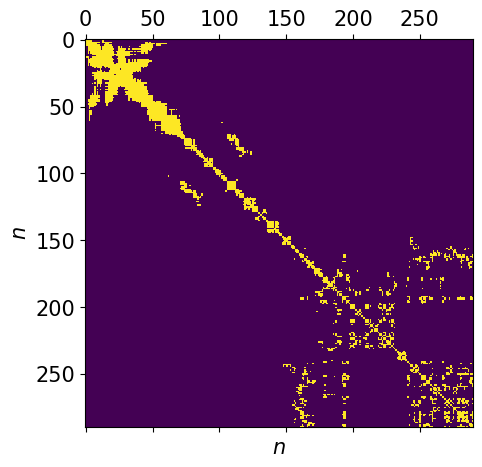

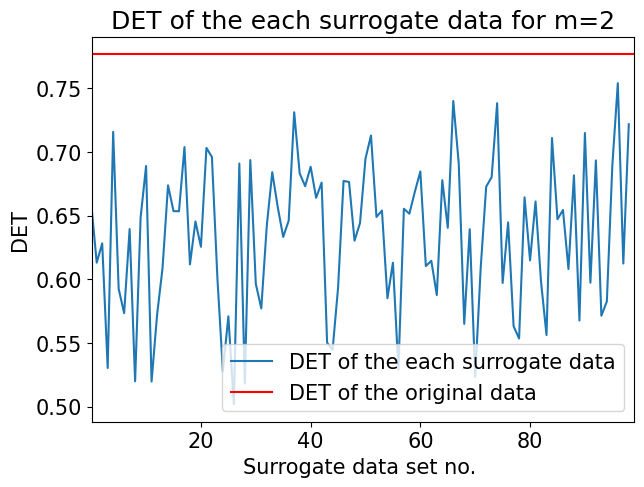

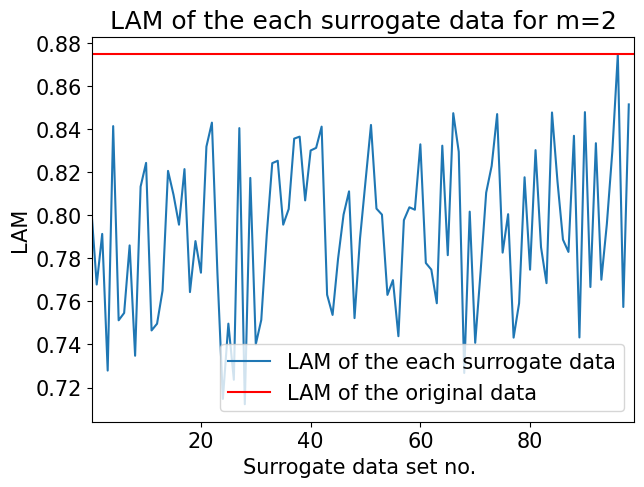

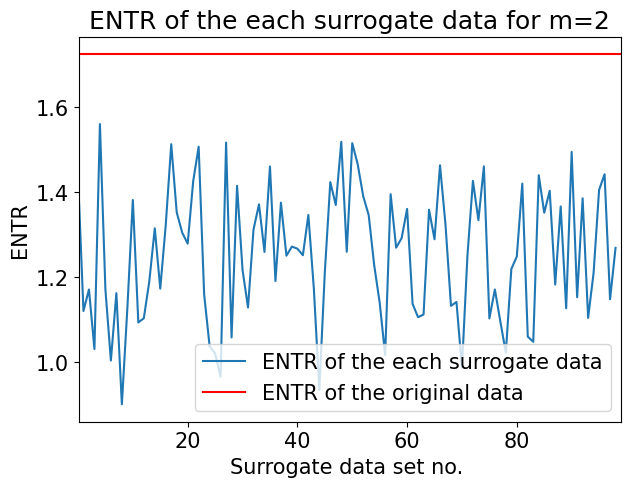

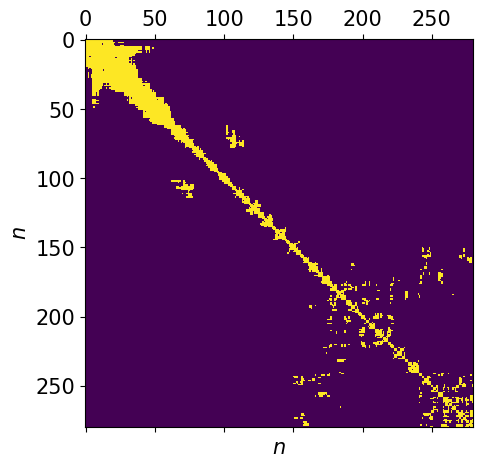

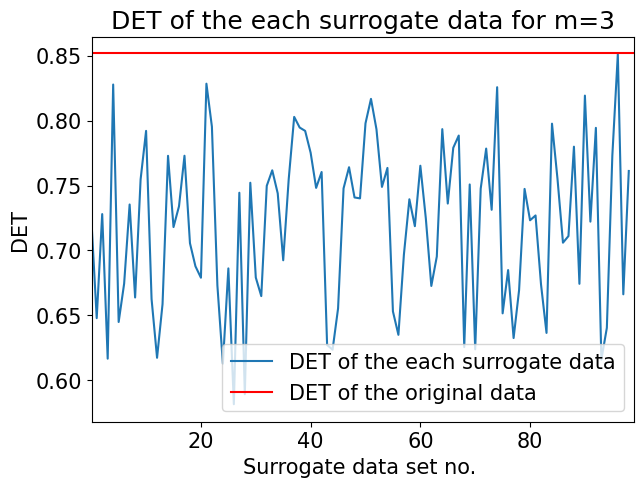

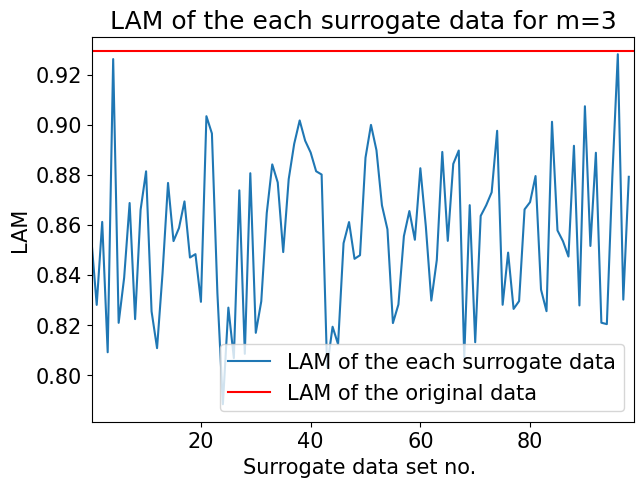

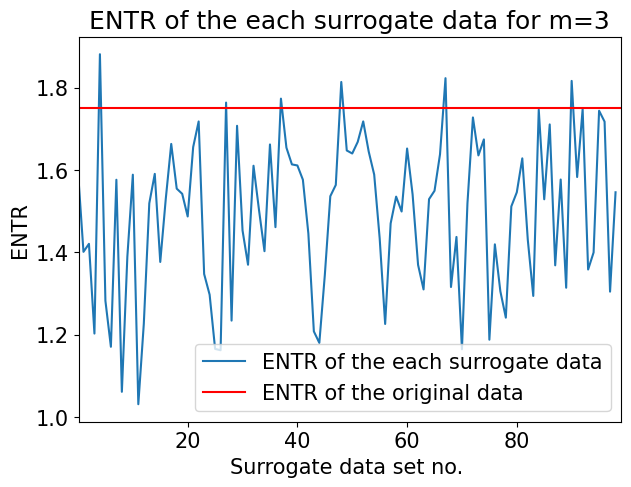

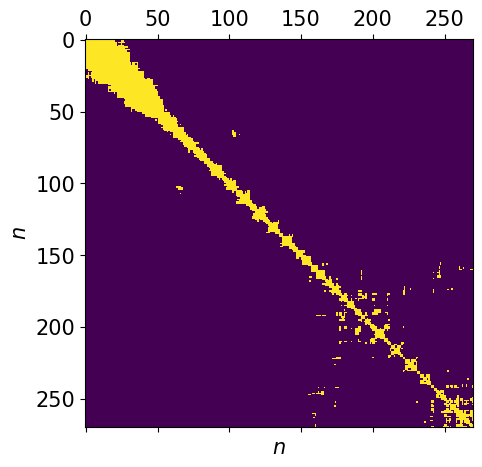

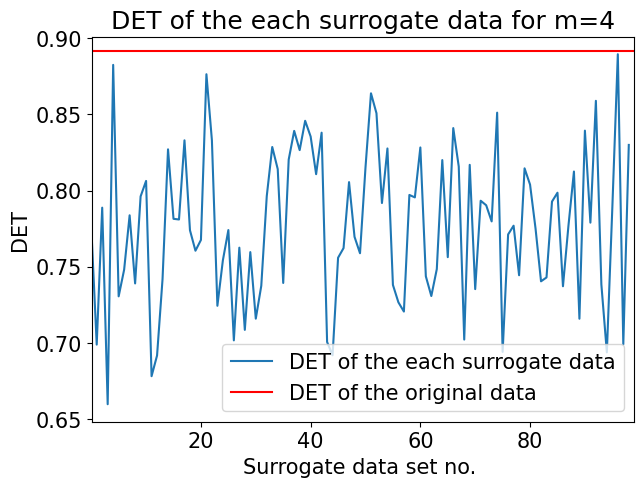

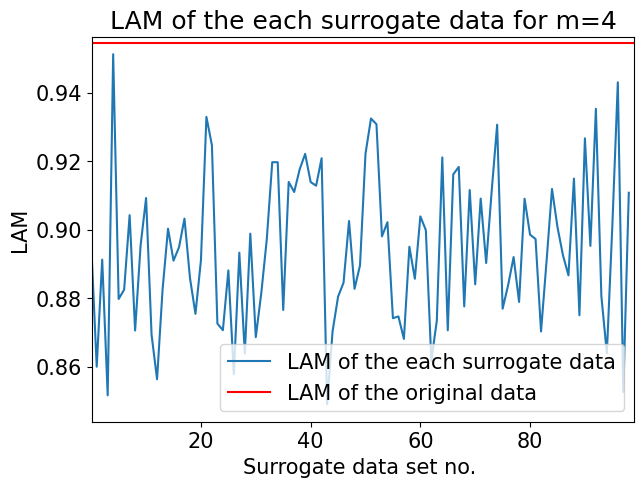

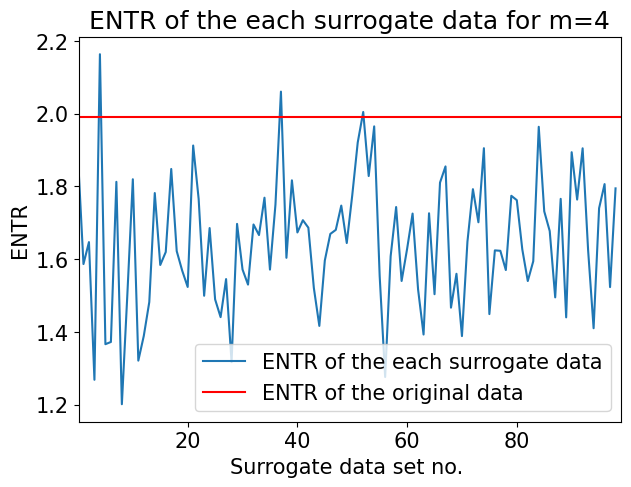

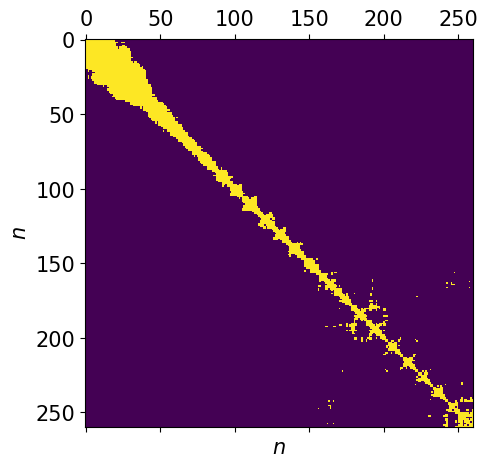

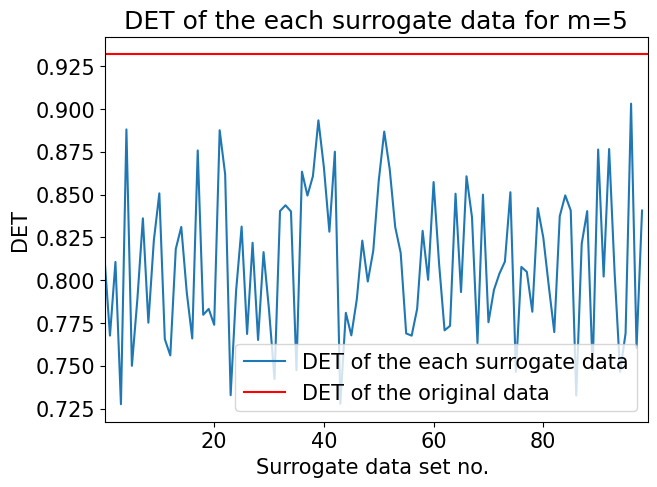

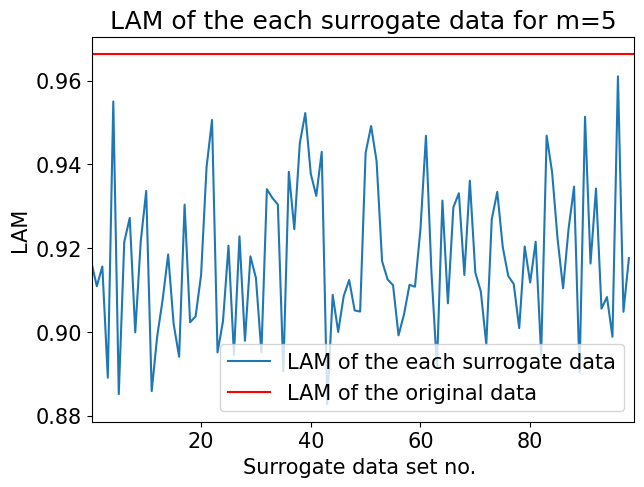

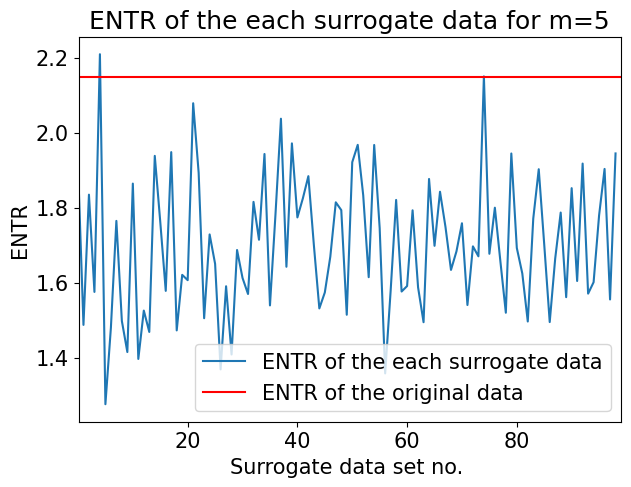

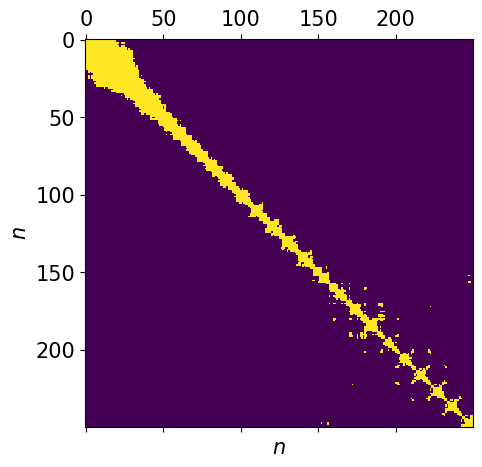

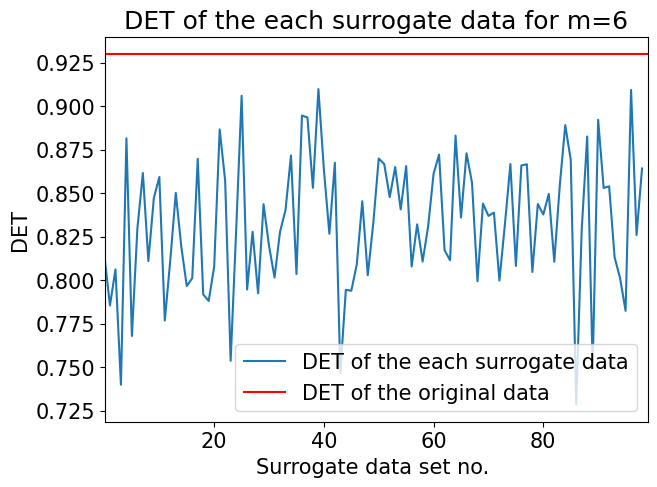

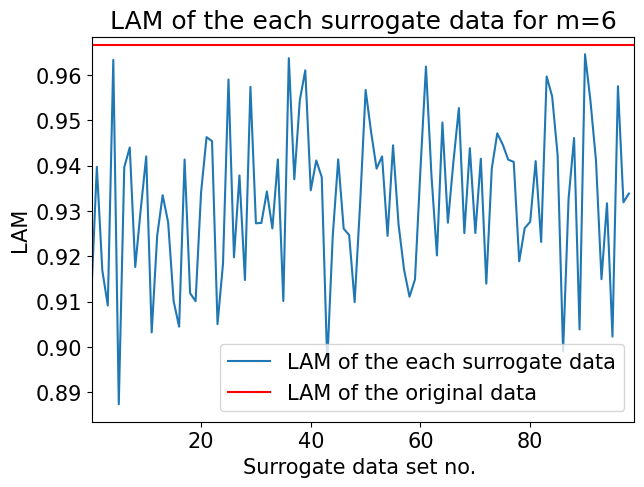

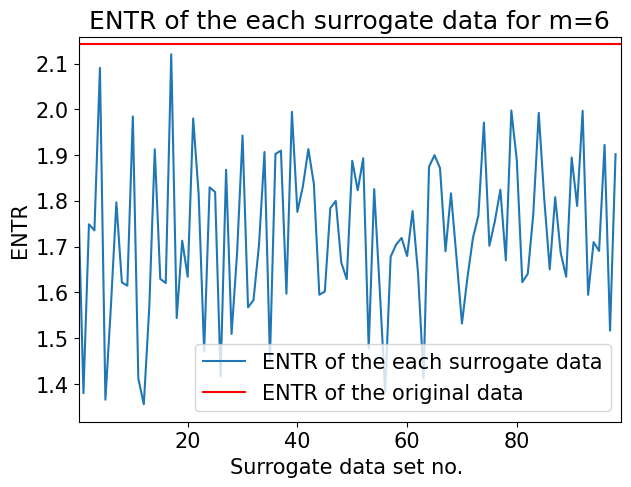

In [12]:
t_min=7
k="stocks"
det_j=[]
embed=[]
ccc=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
f = open("test_output/stocks", "w")
for dim in tqdm(range(2, 8, 1)):
    tt1=0.001
    dimension=dim
    s = lcurve(k)
    orig_rp = RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
    RR_orig = orig_rp.recurrence_rate()
    while RR_orig < 0.05:
        tt1 = tt1 + 0.00001
        det, RR_orig, lam_orig, entr_orig = RP_RN(s, dim, tt1)
    orig_rp = RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
    det_j.append(det)
    embed.append(dim)
    lam_j.append(lam_orig)
    ent_j.append(entr_orig)
    pylab.matshow(orig_rp.recurrence_matrix())
    pylab.xlabel("$n$")
    pylab.ylabel("$n$")
    pylab.savefig('test_output/RP_{}.pdf'.format(dim), format="pdf")
    cc, ff, entr_ff = sur_test(s, dim, tt1)
    fig2, axs = plt.subplots(1)
    axs.plot(cc, label = 'DET of the each surrogate data')
    axs.set_title('DET of the each surrogate data for m={}'.format(dimension))
    axs.axhline(y = det, color = 'r', linestyle = '-', label = 'DET of the original data' )
    axs.legend(loc='lower right')
    axs.set_xlabel("Surrogate data set no. ")
    axs.set_xlim(0.1, 99)
    axs.set_ylabel("DET")
    fig, ax = plt.subplots(1)
    ax.plot(ff, label = 'LAM of the each surrogate data')
    ax.set_title('LAM of the each surrogate data for m={}'.format(dimension))
    ax.axhline(y = lam_orig, color = 'r', linestyle = '-', label = 'LAM of the original data' )
    ax.legend(loc='lower right')
    ax.set_xlabel("Surrogate data set no. ")
    ax.set_xlim(0.1, 99)
    ax.set_ylabel("LAM")
    fi, axx1 = plt.subplots(1)
    axx1.plot(entr_ff, label = 'ENTR of the each surrogate data')
    axx1.set_title('ENTR of the each surrogate data for m={}'.format(dimension))
    axx1.axhline(y = entr_orig, color = 'r', linestyle = '-', label = 'ENTR of the original data' )
    axx1.legend(loc='lower right')
    axx1.set_xlabel("Surrogate data set no. ")
    axx1.set_xlim(0.1, 99)
    axx1.set_ylabel("ENTR")
    r = np.sum(cc >= det)
    r1 = np.sum(ff >= lam_orig)
    r2 = np.sum(entr_ff >= entr_orig)
    p_rank = (r + 1) / (99 + 1)
    p_rank_lam =(r1 + 1) / (99 + 1)
    p_rank_entr = (r2 + 1) / (99 + 1)
    alpha = 0.05
    reject_null1 = p_rank < alpha
    reject_null2 = p_rank_lam < alpha
    reject_null3 = p_rank_entr < alpha
    f = open("test_output/stocks", "a")
    f.write("RQA  {} Embedding dimensions:{} \n DET of original:{} \n Recurrence rate: {} \n Threshold:{} \n Laminarity:{} \n Shannon Entropy:{} \n Rank-order p-value (det):{} \n Rank-order p-value (lam):{} \n Rank-order p-value (entr):{} \nReject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, reject_null3))
    f.close()
    print("RQA  {} Embedding dimensions:{} \n DET of original:{} \n Recurrence rate: {} \n Threshold:{} \n Laminarity:{} \n Shannon Entropy:{} \n Rank-order p-value (det):{} \n Rank-order p-value (lam):{} \n Rank-order p-value (entr):{} \nReject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, reject_null3))
    ccc.append(cc)
    kkk.append(np.full(99, dimension))
    lam_surro.append(ff)
    ent_surro.append(entr_ff)
    fig3, ax3 = plt.subplots(1)
    ax3.scatter(kkk, ccc, color='blue', alpha=0.7, s=5, label = "DET of the each surrogate data")
    ax3.scatter(embed, det_j, color='red', alpha=0.7, s=20, label='DET of the original data')
    ax3.set_xlim(2.9, 6.2)
    ax3.set_xticks(np.arange(3, 7, 1))
    ax3.set_xlabel("Embedding dimension")
    ax3.set_ylabel("DET")
    ax3.legend(loc='lower right')
    fig3.savefig('test_output/surro_m', format="pdf")
    plt.close(fig3)
    fig4, ax4 = plt.subplots(1)
    ax4.scatter(kkk, lam_surro, color='blue', alpha=0.7, s=5, label = "LAM of the each surrogate data")
    ax4.scatter(embed, lam_j, color='red', alpha=0.7, s=20, label='LAM of the original data')
    ax4.set_xlim(2.9, 6.1)
    ax4.set_xlabel("Embedding dimension")
    ax4.set_ylabel("LAM")
    ax4.legend(loc='lower right')
    ax4.set_xticks(np.arange(3, 7, 1))
    fig4.savefig('test_output/surro_lam_m', format="pdf")
    fig5, ax5 = plt.subplots(1)
    ax5.scatter(kkk, ent_surro, color='blue', alpha=0.7, s=5, label = "ENTR of the each surrogate data")
    ax5.scatter(embed, ent_j, color='red', alpha=0.7, s=20, label='ENTR of the original data')
    ax5.set_xlim(2.9, 6.1)
    ax5.set_xlabel("Embedding dimension")
    ax5.set_ylabel("ENTR")
    ax5.legend(loc='lower right')
    ax5.set_xticks(np.arange(3, 7, 1))
    fig5.savefig('test_output/surro_entr_m', format="pdf")
    plt.close(fig4)
    plt.close(fig3)
    plt.close(fig5)

In [ ]:
thr=1.2023
import numpy as np
np.random.seed(0) #added so that the results can be reprucible for gaussian white noise
noise = np.random.normal(0, 1, 300)
np.savetxt("random", noise)
random_rp = RecurrencePlot(noise, dim=4 , tau=1, metric = "euclidean", threshold=thr, normalize=True, silence_level = 3)
print(random_rp.recurrence_rate())
print(random_rp.determinism())




In [ ]:
pylab.matshow(random_rp.recurrence_matrix())
pylab.xlabel("$n$")
pylab.ylabel("$n$")

In [ ]:
t_min=1
k="random"
det_j=[]
embed=[]
ccc=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
f = open("test_output/stocks", "w")
for dim in tqdm(range(2, 7, 1)):
    tt1=0.0001
    dimension=dim
    s = lcurve(k)
    orig_rp = RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
    RR_orig = orig_rp.recurrence_rate()
    print("RQA  {}_{}".format(k, dim))
    while RR_orig < 0.05:
        tt1 = tt1 + 0.0001
        det, RR_orig, lam_orig, entr_orig = RP_RN(s, dim, tt1)
    print(tt1, RR_orig)
    orig_rp = RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
    det_j.append(det)
    embed.append(dim)
    lam_j.append(lam_orig)
    ent_j.append(entr_orig)
    pylab.matshow(orig_rp.recurrence_matrix())
    pylab.xlabel("$n$")
    pylab.ylabel("$n$")
    cc, ff, entr_ff = sur_test(s, dim, tt1)
    fig2, axs = plt.subplots(1)
    axs.plot(cc, label = 'DET of the each surrogate data')
    axs.set_title('DET of the each surrogate data for m={}'.format(dimension))
    axs.axhline(y = det, color = 'r', linestyle = '-', label = 'DET of the original data' )
    axs.legend(loc='lower right')
    axs.set_xlabel("Surrogate data set no. ")
    axs.set_xlim(0.1, 99)
    axs.set_ylabel("DET")
    fig, ax = plt.subplots(1)
    ax.plot(ff, label = 'LAM of the each surrogate data')
    ax.set_title('LAM of the each surrogate data for m={}'.format(dimension))
    ax.axhline(y = lam_orig, color = 'r', linestyle = '-', label = 'LAM of the original data' )
    ax.legend(loc='lower right')
    ax.set_xlabel("Surrogate data set no. ")
    ax.set_xlim(0.1, 99)
    ax.set_ylabel("LAM")
    fi, axx1 = plt.subplots(1)
    axx1.plot(entr_ff, label = 'ENTR of the each surrogate data')
    axx1.set_title('ENTR of the each surrogate data for m={}'.format(dimension))
    axx1.axhline(y = entr_orig, color = 'r', linestyle = '-', label = 'ENTR of the original data' )
    axx1.legend(loc='lower right')
    axx1.set_xlabel("Surrogate data set no. ")
    axx1.set_xlim(0.1, 99)
    axx1.set_ylabel("ENTR")
    r = np.sum(cc >= det)
    r1 = np.sum(ff >= lam_orig)
    r2 = np.sum(entr_ff >= entr_orig)
    p_rank = (r + 1) / (99 + 1)
    p_rank_lam =(r1 + 1) / (99 + 1)
    p_rank_entr = (r2 + 1) / (99 + 1)
    alpha = 0.05
    reject_null1 = p_rank < alpha
    reject_null2 = p_rank_lam < alpha
    reject_null3 = p_rank_entr < alpha
    f = open("test_output/stocks", "a")
    f.write("RQA  {}_{} \n DET of original:{} \n Recurrence rate: {} \n Threshold:{} \n Laminarity:{} \n Shannon's Entropy:{} \n Rank-order p-value (det):{} \n Rank-order p-value (lam):{} \n Rank-order p-value (entr):{} \nReject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, reject_null3))
    f.close()
    print("Rank-order p-value:", p_rank)
    print("Reject null hypothesis:", reject_null1)
    ccc.append(cc)
    kkk.append(np.full(99, dimension))
    lam_surro.append(ff)
    ent_surro.append(entr_ff)
    fig3, ax3 = plt.subplots(1)
    ax3.scatter(kkk, ccc, color='blue', alpha=0.7, s=5, label = "DET of the each surrogate data")
    ax3.scatter(embed, det_j, color='red', alpha=0.7, s=20, label='DET of the original data')
    ax3.set_xlim(2.9, 6.2)
    ax3.set_xticks(np.arange(3, 7, 1))
    ax3.set_xlabel("Embedding dimension")
    ax3.set_ylabel("DET")
    ax3.legend(loc='upper left')
    fig3.savefig('test_output/surro_m', format="pdf")
    plt.close(fig3)
    fig4, ax4 = plt.subplots(1)
    ax4.scatter(kkk, lam_surro, color='blue', alpha=0.7, s=5, label = "LAM of the each surrogate data")
    ax4.scatter(embed, lam_j, color='red', alpha=0.7, s=20, label='LAM of the original data')
    ax4.set_xlim(2.9, 6.1)
    ax4.set_xlabel("Embedding dimension")
    ax4.set_ylabel("LAM")
    ax4.legend(loc='upper left')
    ax4.set_xticks(np.arange(3, 7, 1))
    fig4.savefig('test_output/surro_lam_m', format="pdf")
    fig5, ax5 = plt.subplots(1)
    ax5.scatter(kkk, ent_surro, color='blue', alpha=0.7, s=5, label = "ENTR of the each surrogate data")
    ax5.scatter(embed, ent_j, color='red', alpha=0.7, s=20, label='ENTR of the original data')
    ax5.set_xlim(2.9, 6.1)
    ax5.set_xlabel("Embedding dimension")
    ax5.set_ylabel("ENTR")
    ax5.legend(loc='upper left')
    ax5.set_xticks(np.arange(3, 7, 1))
    fig5.savefig('test_output/surro_entr_m', format="pdf")
    plt.close(fig4)
    plt.close(fig3)
    plt.close(fig5)

CompletedProcess(args=['julia', 'WIAAFT_surrogates.jl'], returncode=0, stdout='', stderr='')